### The goal of any plot is, the critical piece of designing any figure is just to think about, what is the main thing you are tring to convey with the figure. Get to know what the central idea is, then make it really easy to understand.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
names=pd.read_csv('../datasets/names/names.csv')
names[:5]

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [3]:
names.shape

(2149477, 4)

In [4]:
df = names[names.year >= 1950]
df.shape

(1687529, 4)

In [5]:
df[:5]

,name,sex,births,year
461948,Linda,F,80431,1950
461949,Mary,F,65482,1950
461950,Patricia,F,47944,1950
461951,Barbara,F,41555,1950
461952,Susan,F,38017,1950


#### Higher proportion of male babies registered with SSA

In [6]:
df_pct = df.groupby(['sex'])['births'].sum() / df.births.sum() * 100
df_pct

sex
F    48.333078
M    51.666922
Name: births, dtype: float64

In [7]:
df_pct.reset_index(name='percentage_of_births')

,sex,percentage_of_births
0,F,48.333078
1,M,51.666922


In [8]:
total_babies = df.births.sum()
total_babies

273549115

In [9]:
total_males = df[df['sex'] == 'M'].births.sum()
total_males

141334407

In [10]:
male_pct = total_males / total_babies * 100
male_pct

51.666921678763245

In [11]:
total_females = df[df['sex'] == 'F'].births.sum()
total_females

132214708

In [12]:
female_pct = total_females / total_babies * 100
female_pct

48.333078321236755

#### Most popular names
##### Check the most popular name by gender -- 18 out of 20 names most commonly given to males

In [17]:
most_popular_names = df.groupby(['name', 'sex'])['births'].sum().reset_index(name='total_births').sort_values('total_births', ascending=False)
most_popular_names[:20]

,name,sex,total_births
71054,Michael,M,3944505
43193,James,M,2938004
24360,David,M,2922555
48123,John,M,2779358
84476,Robert,M,2595347
104504,William,M,2173942
19952,Christopher,M,2039474
48936,Joseph,M,1737620
23285,Daniel,M,1730530
69205,Matthew,M,1613793


#### Unique names by gender
##### Calculate and plot the number of unique per gender over time

In [25]:
unique_name_per_gender = df.groupby(['year', 'sex'])['name'].nunique().unstack()

In [23]:
df.groupby(['year', 'sex'])['name'].nunique()

year  sex
1950  F       6110
      M       4196
1951  F       6213
      M       4253
1952  F       6390
             ...  
2022  M      14322
2023  F      17597
      M      14206
2024  F      17661
      M      14243
Name: name, Length: 150, dtype: int64

In [24]:
df.groupby(['year', 'sex'])['name'].nunique().unstack()

sex,F,M
year,,
1950,6110,4196
1951,6213,4253
1952,6390,4257
1953,6497,4341
1954,6625,4360
...,...,...
2020,17517,14054
2021,17666,14090
2022,17750,14322


In [26]:
unique_name_per_gender.head()

sex,F,M
year,,
1950,6110,4196
1951,6213,4253
1952,6390,4257
1953,6497,4341
1954,6625,4360


##### This phenomenon is known as statistical dispersion where even though the male names have a higher percentage than female names, the number of unique female baby names is more.
##### There are fewer female babies in this data set but there are more unique names for those female babies every single year.
##### The female baby names are kind of getting spread out among these many names while the male baby names are given these like ultra popular names

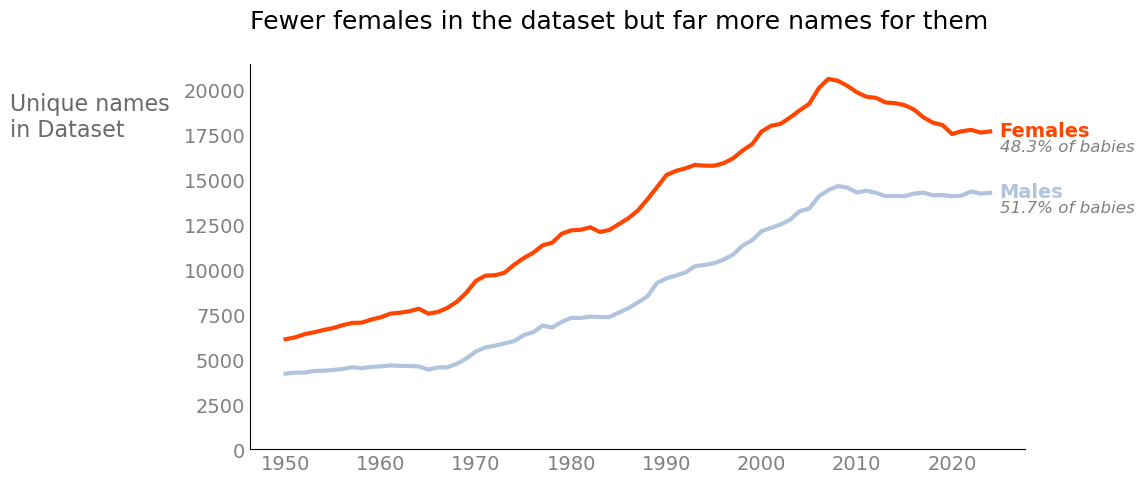

In [89]:
unique_name_per_gender.plot(figsize=(10,5), linewidth=3, color=['orangered', 'lightsteelblue'])
plt.xlabel('')
plt.ylabel('Unique names\nin Dataset', rotation=0, position=(-.5, .8), fontsize=16, ha='left', labelpad=125, color='dimgrey')
plt.title('Fewer females in the dataset but far more names for them\n', fontsize=18, loc='left')

plt.ylim(0, None)
sns.despine()
plt.legend([], frameon=False)
plt.text(2025, 17400, 'Females', color='orangered', fontsize='14', fontweight='bold')
plt.text(2025, 16600, f'{female_pct:.1f}% of babies', fontsize=12, color='gray', fontstyle='italic')
plt.text(2025, 14000, 'Males', color='lightsteelblue', fontsize='14', fontweight='bold')
plt.text(2025, 13200, f'{male_pct:.1f}% of babies', fontsize=12, color='gray', fontstyle='italic')

ax = plt.gca()
ax.tick_params(axis='both', colors='gray', length=0, labelsize=14)

# g = ax.get_yticks()
# plt.yticks(g[1:])

# ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(str(int(x/1000))+'K')))